In [27]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data.load_data import load_feature_data
from src.data.preprocess import PreprocessConfig, preprocess_features

sns.set(style="whitegrid", context="notebook")
print("Setup complete")

Setup complete


In [28]:
loaded = load_feature_data()

print(f"Features shape: {loaded.features.shape}")
print(f"Metadata shape: {loaded.metadata.shape}")
print(f"Missing values: {loaded.features.isna().sum().sum()}")
print(f"Unique individuals: {loaded.metadata['Individual'].nunique()}")

Features shape: (312, 51)
Metadata shape: (312, 19)
Missing values: 2
Unique individuals: 26


### Pipeline A: Global standardization

In [29]:
pp_global = PreprocessConfig(
    imputation_strategy="median",
    scale_features=True,
    scaler="standard",
    subject_center=False,          # global only
    target_type="phase",
)

result_global = preprocess_features(loaded, pp_cfg=pp_global)

print("Pipeline A: Global standardization")
print(f"  X shape: {result_global.X.shape}")
print(f"  y shape: {result_global.y.shape}")
print(f"  y values: {np.unique(result_global.y)}")
print(f"  Features: {len(result_global.feature_names)}")
print(f"  X mean (col 0): {result_global.X[:, 0].mean():.6f}")
print(f"  X std  (col 0): {result_global.X[:, 0].std():.6f}")

Pipeline A: Global standardization
  X shape: (312, 51)
  y shape: (312,)
  y values: [0 1 2]
  Features: 51
  X mean (col 0): 0.000000
  X std  (col 0): 1.000000


**Note:** Global standardization centers all 312 observations to zero mean and unit variance 
per feature. This treats all participants as coming from the same distribution, meaning 
inter-subject baseline differences remain in the data.

### Pipeline B: Subject-center and standardization

In [30]:
pp_centered = PreprocessConfig(
    imputation_strategy="median",
    scale_features=True,
    scaler="standard",
    subject_center=True,           # per-participant centering
    target_type="phase",
)

result_centered = preprocess_features(loaded, pp_cfg=pp_centered)

print("Pipeline B: Subject-centered + standardization")
print(f"  X shape: {result_centered.X.shape}")
print(f"  y shape: {result_centered.y.shape}")
print(f"  X mean (col 0): {result_centered.X[:, 0].mean():.6f}")
print(f"  X std  (col 0): {result_centered.X[:, 0].std():.6f}")

Pipeline B: Subject-centered + standardization
  X shape: (312, 51)
  y shape: (312,)
  X mean (col 0): 0.000000
  X std  (col 0): 1.000000


**note:** Subject-centering first subtracts each participant's mean feature vector, then applies global standardization. This removes individual physiological baselines (for example, person A's resting HR of 70 bpm vs person B's resting HR of 90 bpm) and isolates within-subject, phase-related variatin

### verifying if suject-centering worked

In [32]:
# after centering, each individual's mean should be ~0
# verifying on the un-scaled centered data
pp_check = PreprocessConfig(
    imputation_strategy="median",
    scale_features=False,          # don't scale, just center
    subject_center=True,
    target_type="none",
)
result_check = preprocess_features(loaded, pp_cfg=pp_check)

check_df = pd.DataFrame(result_check.X, columns=result_check.feature_names)
check_df["Individual"] = loaded.metadata["Individual"].values
individual_means = check_df.groupby("Individual").mean()

print(f"Max absolute individual mean after centering: "
      f"{individual_means.abs().max().max():.10f}")

Max absolute individual mean after centering: 0.0000000000


**Note:** It pased the verification as after subject-centering, every individual's mean feature vector is exactly zero.

C:\Users\PJS\AppData\Local\Temp\ipykernel_16072\1751115723.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(
C:\Users\PJS\AppData\Local\Temp\ipykernel_16072\1751115723.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(


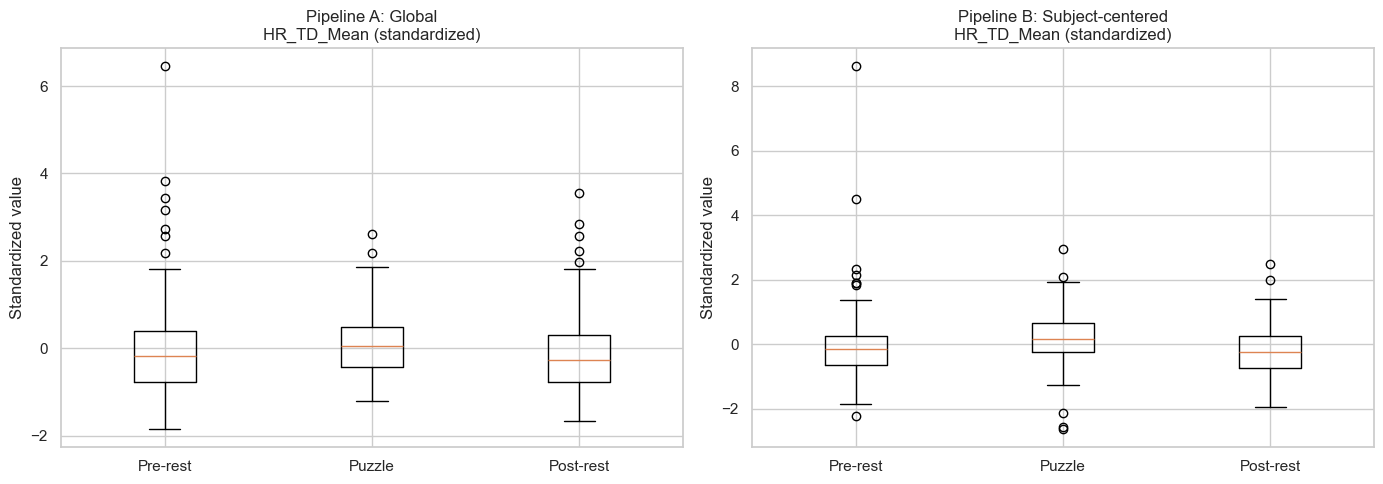

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

feat_idx = result_global.feature_names.index("HR_TD_Mean")
meta = result_global.metadata

# Pipeline A
axes[0].boxplot(
    [result_global.X[meta["Phase"] == p, feat_idx] for p in ["phase1", "phase2", "phase3"]],
    labels=["Pre-rest", "Puzzle", "Post-rest"]
)
axes[0].set_title("Pipeline A: Global\nHR_TD_Mean (standardized)")
axes[0].set_ylabel("Standardized value")

# Pipeline B
axes[1].boxplot(
    [result_centered.X[meta["Phase"] == p, feat_idx] for p in ["phase1", "phase2", "phase3"]],
    labels=["Pre-rest", "Puzzle", "Post-rest"]
)
axes[1].set_title("Pipeline B: Subject-centered\nHR_TD_Mean (standardized)")
axes[1].set_ylabel("Standardized value")

plt.tight_layout()
plt.show()

**Observation:** Under global standardization, HR_TD_Meanshows no visible difference between phases as inter-subject variability dominates. After subject-centering, the puzzle shows a small upward shift in median HR relative to pre-rest and post-rest, consistent with mild physiological changes dusring competitive task solving

In [35]:
# saving both pipelines

from src.data.preprocess import save_processed_features

paths_global = save_processed_features(result_global, prefix="pipeline_A_global")
paths_centered = save_processed_features(result_centered, prefix="pipeline_B_centered")

print("Saved Pipeline A:", paths_global)
print("Saved Pipeline B:", paths_centered)


Saved Pipeline A: {'X_path': WindowsPath('C:/Users/PJS/ComputationalDataAnalysis/02582_Case2_Group-2/data/processed/pipeline_A_global_X.npy'), 'y_path': WindowsPath('C:/Users/PJS/ComputationalDataAnalysis/02582_Case2_Group-2/data/processed/pipeline_A_global_y.npy'), 'metadata_path': WindowsPath('C:/Users/PJS/ComputationalDataAnalysis/02582_Case2_Group-2/data/processed/pipeline_A_global_metadata.csv'), 'info_path': WindowsPath('C:/Users/PJS/ComputationalDataAnalysis/02582_Case2_Group-2/data/processed/pipeline_A_global_info.json')}
Saved Pipeline B: {'X_path': WindowsPath('C:/Users/PJS/ComputationalDataAnalysis/02582_Case2_Group-2/data/processed/pipeline_B_centered_X.npy'), 'y_path': WindowsPath('C:/Users/PJS/ComputationalDataAnalysis/02582_Case2_Group-2/data/processed/pipeline_B_centered_y.npy'), 'metadata_path': WindowsPath('C:/Users/PJS/ComputationalDataAnalysis/02582_Case2_Group-2/data/processed/pipeline_B_centered_metadata.csv'), 'info_path': WindowsPath('C:/Users/PJS/ComputationalD

In [36]:
# cehcking for constant or non-constant features

print(f"Pipeline A (global):          X shape = {result_global.X.shape}")
print(f"Pipeline B (subject-centered): X shape = {result_centered.X.shape}")
print(f"Target y:                      {np.unique(result_global.y)} "
      f"(0=pre-rest, 1=puzzle, 2=post-rest)")
print(f"Feature count:                 {len(result_global.feature_names)}")


Pipeline A (global):          X shape = (312, 51)
Pipeline B (subject-centered): X shape = (312, 51)
Target y:                      [0 1 2] (0=pre-rest, 1=puzzle, 2=post-rest)
Feature count:                 51
